In [1]:
# =========================================================
# CONFIGURATION & HYPER-PARAMETERS FOR SHAP/LIME EXPLAINABILITY
# =========================================================
import os, sys
import torch
import numpy as np
import pandas as pd

# Add repository root to python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))

# Configurable experiment settings
DATASET_NAME = "VSFC-Ekman"
SEED = 0
RDF_PATH = "ontology/ekman_appraisal_ontology.rdf"
CHECKPOINT_PATH = "results/vsfc_ekman_raw_gate_m3.pth"
EXPLAIN_SENTENCE = "giảng viên nhiệt tình trong công tác giảng dạy ."

# Set random seed for reproducibility
def seed_everything(seed=42):
    import random
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Configured environment for {DATASET_NAME} (Seed: {SEED}) on device: {device}")


/kaggle/input/models/thnhcng123/kg-phobert/other/default/1/phobert_gate_m3.pth
/kaggle/input/models/thnhcng123/kg-phobert/other/default/1/vsfc_ekman_raw_gate_m3.pth
/kaggle/input/models/thnhcng123/kg-phobert/other/default/1/vsmec_gate_m3.pth
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_5.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_7.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_4.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_9.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_6.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_8.rdf
/kaggle/input/datasets/minkduck/vsfcekman-1/dev.csv
/kaggle/input/datasets/minkduck/vsfcekman-1/train.csv
/kaggle/input/datasets/minkduck/vsfcekman-1/test.csv
/kaggle/input/datasets/minkduck/kgvsfcekman/ekman6_vsfc_2.rdf
/kaggle/input/datasets/minkduck/kgvsfcekman/ekman6_vsfc_4.rdf
/kaggle/input/datasets/minkduck/kgvsfcekman/ekman6_2_vsfc_3.rdf
/kaggle/input/datasets/minkduck/kgvsfcekman/ekman6_vsfc_weighted.rdf


In [2]:
# !pip install -q pyvi rdflib unidecode


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 62.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.7 MB/s eta 0:00:00


In [3]:
# ---------------------------------------------------------
# CELL 1: SETUP & DEPENDENCIES
# ---------------------------------------------------------

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import copy
import re
import rdflib
from rdflib import Graph, Namespace, RDF, RDFS
from pyvi import ViTokenizer
from unidecode import unidecode
import os
import random

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(2025)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [4]:
# =========================================================
# CELL 2: ONTOLOGY ENGINE V12.2 (VSFC EDITION)
# Logic: Deep Inference (Suy diễn sâu) + Soft Polarity.
# Target: Tối ưu cho bài toán Sentiment 3 nhãn (Pos/Neg/Neu).
# Input: ekman6_4_8.rdf
# =========================================================
# !pip install -q pyvi rdflib unidecode

import os, re
import numpy as np
import rdflib
from rdflib import Graph, Namespace
from rdflib.namespace import RDF, RDFS, OWL
from pyvi import ViTokenizer
from unidecode import unidecode

class OntologyEngine:
    def __init__(self, rdfpath, defaultconf=0.85, manual_boost=1.2, negation_attenuation=0.5, alpha_similarity=0.2, verbose=True):
        self.EKMAN = Namespace("http://example.org/ekman-ontology#")
        self.defaultconf = float(defaultconf)
        self.manual_boost = float(manual_boost)
        self.negation_attenuation = float(negation_attenuation) 
        self.alpha_similarity = float(alpha_similarity)
        self.verbose = bool(verbose)

        # 1. CONFIGS
        self.ALLEMOTIONS = ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]
        self.ALLAPPRAISALS = [
            "GoalObstructionAppraisal", "PleasantnessAppraisal", "UnpleasantnessAppraisal", 
            "DangerousnessAppraisal", "LossAppraisal", "SuddennessAppraisal", 
            "LowPredictabilityAppraisal", "UnpredictabilityAppraisal", "UnfairnessAppraisal"
        ]
        self.INTENSITY_CLASSES = ["HighIntensity", "MediumIntensity", "LowIntensity"]
        
        # VSFC Rất cần 3 cột này chuẩn xác
        self.POLARITY_CLASSES = ["PositivePolarity", "NegativePolarity", "NeutralPolarity"]

        self.EMOTIONMAPPING = {
            "Enjoyment": "Happiness", "Happiness": "Happiness", "Anger": "Anger", "Disgust": "Disgust", 
            "Fear": "Fear", "Sadness": "Sadness", "Surprise": "Surprise", 
            "NeutralEmotion": "Neutral", "Neutral": "Neutral", "Other": "Neutral", "NegationCue": "NegationCue"
        }
        
        # [QUAN TRỌNG VỚI VSFC] Suy diễn Polarity nếu thiếu
        # Vì VSFC là bài toán Sentiment, việc map Emotion -> Polarity là bắt buộc
        self.IMPLIED_POLARITY = {
            # Emotion -> Polarity
            "Anger": "NegativePolarity", "Disgust": "NegativePolarity",
            "Fear": "NegativePolarity", "Sadness": "NegativePolarity",
            "Happiness": "PositivePolarity", "Enjoyment": "PositivePolarity",
            "Surprise": "PositivePolarity", 
            # Appraisal -> Polarity
            "UnpleasantnessAppraisal": "NegativePolarity",
            "GoalObstructionAppraisal": "NegativePolarity", 
            "LossAppraisal": "NegativePolarity",
            "UnfairnessAppraisal": "NegativePolarity",
            "DangerousnessAppraisal": "NegativePolarity",
            "PleasantnessAppraisal": "PositivePolarity"
        }
        
        self.AMBIGUOUS_TERMS = {
            "hay", "chả", "cơ", "ngờ", "ý", "quá", "lại", 
            "tôi", "tao", "tớ", "mình", "bạn", "nó", "hắn", "anh", "chị", "em",
            "là", "thì", "mà", "bị", "được", "cái", "con", "người"
        }
        
        self.VALID_DOMAINS = {"GeneralDomain", "SocialDomain", "EducationDomain"}
        
        # LOAD KG
        if self.verbose: print(f"📥 Loading KG for VSFC: {rdfpath}")
        self.g = Graph()
        if os.path.exists(rdfpath):
            self.g.parse(rdfpath)
            if self.verbose: print(f"   ✅ Loaded {len(self.g)} triples.")
        else:
            print(f"   ⚠️ ERROR: File not found {rdfpath}")

        self.sim_matrix = self._build_similarity_matrix()
        self.lexiconmap = self._build_strict_lexicon()
        
        self.mwe_max_len = 1
        for k in self.lexiconmap.keys(): self.mwe_max_len = max(self.mwe_max_len, len(k.split()))
        if self.verbose: print(f"   📚 Lexicon size: {len(self.lexiconmap)} entries (v12.2 VSFC-Ready)")

    def _norm(self, s): return re.sub(r"\s+", " ", str(s).lower().strip().replace("_", " ")).strip() if s else ""
    def _local(self, uri): return str(uri).split("#")[-1] if "#" in str(uri) else str(uri).split("/")[-1]

    def _build_similarity_matrix(self):
        n = len(self.ALLEMOTIONS)
        mat = np.zeros((n, n), dtype=np.float32); np.fill_diagonal(mat, 1.0)
        try:
            q = """PREFIX ekman: <http://example.org/ekman-ontology#> SELECT ?score ?e1 ?e2 WHERE { ?edge a ekman:EmotionSimilarityEdge ; ekman:similarityScore ?score ; ekman:linksEmotion ?e1 ; ekman:linksEmotion ?e2 . }"""
            for row in self.g.query(q):
                e1, e2 = self.EMOTIONMAPPING.get(self._local(row.e1)), self.EMOTIONMAPPING.get(self._local(row.e2))
                if e1 in self.ALLEMOTIONS and e2 in self.ALLEMOTIONS:
                    i, j = self.ALLEMOTIONS.index(e1), self.ALLEMOTIONS.index(e2)
                    mat[i, j] = mat[j, i] = max(mat[i, j], float(row.score))
        except: pass
        s = mat.sum(axis=1, keepdims=True); s[s==0] = 1.0
        return mat / s

    def _build_strict_lexicon(self):
        EK, lookup = self.EKMAN, {}
        mix_cache, sim_cache = {}, {}
        
        for r in self.g.query("PREFIX ekman: <http://example.org/ekman-ontology#> SELECT ?m ?e ?w WHERE { ?m a ekman:EmotionMixture ; ekman:hasComponent ?c . ?c ekman:componentEmotion ?e ; ekman:componentWeight ?w . }"):
            m, e, w = r.m, self.EMOTIONMAPPING.get(self._local(r.e)), float(r.w)
            if e in self.ALLEMOTIONS: mix_cache.setdefault(m, {})[e] = mix_cache.setdefault(m, {}).get(e, 0.0) + w
        
        for s, _, o in self.g.triples((None, EK.hasEmotionCategory, None)):
            e = self.EMOTIONMAPPING.get(self._local(o))
            if e in self.ALLEMOTIONS: sim_cache[s] = [e]
            
        for s in self.g.subjects(RDF.type, None):
            if s in mix_cache or s in sim_cache: continue
            ts = list(self.g.objects(s, RDF.type))
            if EK.NegationCue in ts: sim_cache[s] = ["NegationCue"]
            else:
                for t in ts:
                    m = self.EMOTIONMAPPING.get(self._local(t))
                    if m in self.ALLEMOTIONS: sim_cache[s] = [m]; break
        
        q = """PREFIX ekman: <http://example.org/ekman-ontology#> SELECT ?word ?stim ?ev ?base ?type ?dom WHERE { ?evoc a ekman:Evocation ; ekman:fromLexiconEntry ?lex ; ekman:toStimulus ?stim . ?lex ekman:hasContent ?word . OPTIONAL { ?evoc ekman:confidenceScore ?ev } OPTIONAL { ?evoc ekman:evidenceType ?type } OPTIONAL { ?lex ekman:baseIntensityScore ?base } OPTIONAL { ?lex ekman:belongsToDomain ?dom } }"""
        for r in self.g.query(q):
            if r.dom and self._local(r.dom) not in self.VALID_DOMAINS: continue 
            w = self._norm(r.word)
            if len(w) < 2 or w in self.AMBIGUOUS_TERMS: continue
            
            emos = {}
            if r.stim in mix_cache:
                raw = mix_cache[r.stim]; tot = sum(raw.values())
                if tot > 0: emos = {k: v/tot for k, v in raw.items()}
            elif r.stim in sim_cache:
                lst = sim_cache[r.stim]
                emos = {k: 1.0 for k in lst}
            if not emos: continue

            # Deep Inference
            apps, ints, pols = self._infer_attributes(r.stim, emos.keys())
            
            entry_score = float(r.ev or self.defaultconf) * float(r.base or 1.0)
            
            entry = {"emotions": emos, "score": entry_score, 
                     "appraisals": list(apps), "intensities": list(ints), "polarities": list(pols), 
                     "isnegation": "NegationCue" in emos}
            lookup.setdefault(w, []).append(entry)
            wu = self._norm(unidecode(w))
            if wu != w: lookup.setdefault(wu, []).append(entry)
        return lookup

    def _infer_attributes(self, s, emos):
        EK, a, i, p = self.EKMAN, set(), set(), set()
        
        # 1. Direct
        def g(r):
            for o in self.g.objects(r, EK.evokesAppraisal): a.add(self._local(o))
            for o in self.g.objects(r, EK.hasIntensity): i.add(self._local(o))
            for o in self.g.objects(r, EK.hasPolarity): p.add(self._local(o))
        g(s)
        for t in self.g.objects(s, RDF.type): g(t)
        
        # 2. Deep Inference (Quan trọng cho VSFC)
        if not p:
            for e in emos:
                if e in self.IMPLIED_POLARITY: p.add(self.IMPLIED_POLARITY[e])
        if not p:
            for app in a:
                if app in self.IMPLIED_POLARITY: p.add(self.IMPLIED_POLARITY[app])

        return a, i, p

    def getvector(self, text, debug=False):
        tokens = ViTokenizer.tokenize(str(text).lower()).split()
        flat = [self._norm(t) for t in tokens if self._norm(t)]
        
        ve, va, vi = np.zeros(7, dtype=np.float32), np.zeros(9, dtype=np.float32), np.zeros(3, dtype=np.float32)
        vp, vn = np.zeros(3, dtype=np.float32), np.zeros(2, dtype=np.float32)
        
        idx, n = 0, len(flat)
        hit_trace = []

        while idx < n:
            m, ml = None, 0
            for L in range(min(self.mwe_max_len, n-idx), 0, -1):
                p = " ".join(flat[idx:idx+L])
                if p in self.lexiconmap: m, ml = self.lexiconmap[p], L; break
            
            if not m:
                idx += 1; continue
            
            if debug: hit_trace.append({"phrase": " ".join(flat[idx:idx+ml]), "data": m[0]})

            for ent in m:
                if ent["isnegation"]:
                    vn[0] = 1.0; continue
                
                sc = ent["score"]
                if vn[0] > 0: sc *= self.negation_attenuation 
                
                for e, w in ent["emotions"].items():
                    if e in self.ALLEMOTIONS: ve[self.ALLEMOTIONS.index(e)] += sc * w
                for x in ent["appraisals"]:
                    if x in self.ALLAPPRAISALS: va[self.ALLAPPRAISALS.index(x)] += sc
                for x in ent["intensities"]:
                    if x in self.INTENSITY_CLASSES: vi[self.INTENSITY_CLASSES.index(x)] = 1.0
                
                # Soft Polarity (Quan trọng)
                for x in ent["polarities"]:
                    if x in self.POLARITY_CLASSES: vp[self.POLARITY_CLASSES.index(x)] += sc 
            idx += ml

        if self.alpha_similarity > 0: ve = np.clip(ve + self.alpha_similarity * (ve @ self.sim_matrix), 0, None)
        fin = np.concatenate([np.tanh(ve), np.tanh(va), vi, vp, vn]).astype(np.float32)
        return (fin, flat, hit_trace) if debug else fin

# KHỞI TẠO (Dùng file 6_4_8)
RDFPATH = RDF_PATH
if os.path.exists(RDFPATH):
    print(f"🚀 Initializing OntologyEngine v12.2 for VSFC (Deep Inference) with {RDFPATH}...")
    ontengine = OntologyEngine(RDFPATH, verbose=True)
else:
    print(f"❌ ERROR: File not found {RDFPATH}")

🚀 Initializing OntologyEngine v12.2 for VSFC (Deep Inference) with /kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_8.rdf...
📥 Loading KG for VSFC: /kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_8.rdf
   ✅ Loaded 90420 triples.
   📚 Lexicon size: 2540 entries (v12.2 VSFC-Ready)


In [5]:
# ---------------------------------------------------------
# CELL 3: DATASET & DATALOADER
# ---------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, ontology_engine, max_len=128):
        self.df = df
        self.tokenizer = tokenizer
        self.ont_engine = ontology_engine
        self.max_len = max_len
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        raw_text = str(self.df.iloc[index]['Sentence'])
        label = self.df.iloc[index]['label_idx']
        
        encoding = self.tokenizer(
            raw_text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Gọi hàm getvector (đã sửa tên đúng)
        ont_vector = self.ont_engine.getvector(raw_text) 
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'ontology_features': torch.tensor(ont_vector, dtype=torch.float),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Load Data
try:
    base_path = "data/vsfc-ekman" # Check path
    df_train = pd.read_csv(f"{base_path}/train.csv")
    df_valid = pd.read_csv(f"{base_path}/dev.csv")
    df_test = pd.read_csv(f"{base_path}/test.csv")
    
    for df in [df_train, df_valid, df_test]:
        df.rename(columns={'Text': 'Sentence', 'Ekman_Label': 'Emotion'}, inplace=True)
        df.dropna(subset=['Sentence', 'Emotion'], inplace=True)
    
    print("✅ Loaded Datasets.")
except Exception as e:
    print(f"❌ Error loading data: {e}")

# Label Encoding
le = LabelEncoder()
all_labels = sorted(df_train['Emotion'].unique().astype(str))
le.fit(all_labels)
print(f"📋 Classes: {le.classes_}")

for df in [df_train, df_valid, df_test]:
    df['label_idx'] = le.transform(df['Emotion'].astype(str))

# Dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(EmotionDataset(df_train, tokenizer, ontengine), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(EmotionDataset(df_valid, tokenizer, ontengine), batch_size=BATCH_SIZE)
test_loader = DataLoader(EmotionDataset(df_test, tokenizer, ontengine), batch_size=BATCH_SIZE)

# Class Weights
train_labels = df_train['label_idx'].tolist()
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"⚖️ Weights: {weights_tensor}")

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Loaded Datasets.
📋 Classes: ['Anger' 'Disgust' 'Fear' 'Happiness' 'Neutral' 'Sadness' 'Surprise']
⚖️ Weights: tensor([ 0.7617,  2.6327, 41.8535,  0.2899,  3.5717,  0.6545, 38.8639],
       device='cuda:0')


In [6]:
# ---------------------------------------------------------
# CELL 4: MODEL (xAI & DENSE SUPPORT)
# ---------------------------------------------------------
try: ONT_INPUT_DIM = len(ontengine.getvector("t"))
except: ONT_INPUT_DIM = 24

class PhoBERT_Fusion_V2(nn.Module):
    def __init__(self, n_classes, fusion_type='none', ontology_dim=None, ont_input_dim=ONT_INPUT_DIM):
        super(PhoBERT_Fusion_V2, self).__init__()
        self.fusion_type = fusion_type
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base-v2")
        self.dropout = nn.Dropout(p=0.3)
        
        # Ontology Adapter
        if ontology_dim: # Dense Mode (64d)
            self.ont_adapter = nn.Sequential(
                nn.Linear(ont_input_dim, ontology_dim),
                nn.BatchNorm1d(ontology_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            )
            self.curr_dim = ontology_dim
        else: # Raw Mode (xAI)
            self.ont_adapter = nn.Identity()
            self.curr_dim = ont_input_dim
            
        # Fusion
        if self.fusion_type == 'gate':
            self.gate = nn.Linear(768, self.curr_dim)
            
        # Head
        inp = 768 + self.curr_dim if self.fusion_type != 'none' else 768
        self.fc = nn.Linear(inp, n_classes)

    def forward(self, ids, mask, ont):
        _, txt = self.phobert(ids, mask, return_dict=False)
        txt = self.dropout(txt)
        
        if self.fusion_type == 'none': return self.fc(txt)
        
        ont_emb = self.ont_adapter(ont)
        if self.fusion_type == 'gate':
            g = torch.sigmoid(self.gate(txt))
            ont_emb = ont_emb * g
            
        comb = torch.cat([txt, ont_emb], dim=1)
        return self.fc(comb)

In [7]:
# ---------------------------------------------------------
# CELL 5: TRAINING HELPER FUNCTIONS (EARLY STOPPING)
# ---------------------------------------------------------
from sklearn.metrics import accuracy_score, f1_score

def train_experiment(model, name, epochs=20, patience=3):
    print(f"\n🚀 Bắt đầu huấn luyện: {name}")
    print(f"   (Cấu hình: Max Epochs={epochs}, Patience={patience})")

    # Bọc DataParallel nếu GPU > 1
    if torch.cuda.device_count() > 1:
        print(f"⚡ Đang chạy trên {torch.cuda.device_count()} GPUs!")
        model = nn.DataParallel(model)
    
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    
    best_f1 = 0
    # Copy weights ban đầu
    if isinstance(model, nn.DataParallel):
        best_model_wts = copy.deepcopy(model.module.state_dict())
    else:
        best_model_wts = copy.deepcopy(model.state_dict())
        
    patience_counter = 0 
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            ont = batch['ontology_features'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            outputs = model(input_ids, mask, ont)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        # Đánh giá sau mỗi epoch
        val_acc, val_f1 = evaluate(model, valid_loader)
        avg_loss = total_loss / len(train_loader)
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}", end=" ")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            if isinstance(model, nn.DataParallel):
                best_model_wts = copy.deepcopy(model.module.state_dict())
            else:
                best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0 
            print("✅ New Best!")
        else:
            patience_counter += 1
            print(f"⚠️ No improve ({patience_counter}/{patience})")
            
        if patience_counter >= patience:
            print(f"\n🛑 Early Stopping triggered! (Không cải thiện sau {patience} epochs)")
            break
            
    print(f"🏆 Kết thúc {name}. Best Val F1: {best_f1:.4f}")
    
    # Load lại best weights trước khi trả về
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(best_model_wts)
    else:
        model.load_state_dict(best_model_wts)
        
    return model

def evaluate(model, loader):
    model.eval()
    preds = []
    truths = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            ont = batch['ontology_features'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, mask, ont)
            _, pred = torch.max(outputs, dim=1)
            
            preds.extend(pred.cpu().numpy())
            truths.extend(labels.cpu().numpy())
            
    return accuracy_score(truths, preds), f1_score(truths, preds, average='macro')

In [8]:
import pandas as pd

basepath = "data/vsfc-ekman"

dftrain = pd.read_csv(f"{basepath}/train.csv")
dfvalid = pd.read_csv(f"{basepath}/dev.csv")
dftest  = pd.read_csv(f"{basepath}/test.csv")

# chuẩn hoá tên cột theo notebook của bạn
for df in [dftrain, dfvalid, dftest]:
    df.rename(columns={"Text": "Sentence", "Ekman_Label": "Emotion"}, inplace=True)

# bỏ NA
for df in [dftrain, dfvalid, dftest]:
    df.dropna(subset=["Sentence", "Emotion"], inplace=True)

print(len(dftrain), len(dfvalid), len(dftest))
print(dftrain.columns)
print(dftrain.head(2))


11426 1583 3166
Index(['Sentence', 'Original_Sentiment', 'Emotion'], dtype='object')
                                         Sentence  Original_Sentiment  \
0                       slide giáo trình đầy đủ .                   2   
1  nhiệt tình giảng dạy , gần gũi với sinh viên .                   2   

     Emotion  
0  Happiness  
1  Happiness  


In [9]:
import numpy as np
import pandas as pd

def add_onto_stats(df, ontengine, text_col="Sentence", eps=1e-6):
    # trả về df mới có các cột thống kê ontology
    rows = []
    for text in df[text_col].astype(str).tolist():
        v = ontengine.getvector(text)
        av = np.abs(v)

        rows.append({
            "onto_any": float(av.sum() > eps),
            "onto_emotion": float(av[:7].sum() > eps),
            "onto_appraisal": float(av[7:16].sum() > eps),
            "onto_negcue": float(av[-2] > 0.5),          # vn[0]
            "onto_nnz": int((av > eps).sum()),
        })
    out = df.copy()
    out = pd.concat([out.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
    return out

def coverage_by_label(df, label_col="Emotion"):
    g = df.groupby(label_col, dropna=False)
    rep = g.agg(
        N=(label_col, "size"),
        coverage_any_pct=("onto_any", "mean"),
        coverage_emotion_pct=("onto_emotion", "mean"),
        coverage_appraisal_pct=("onto_appraisal", "mean"),
        negcue_rate_pct=("onto_negcue", "mean"),
        avg_nnz_dims=("onto_nnz", "mean"),
    ).reset_index()

    # đổi mean -> %
    for c in ["coverage_any_pct","coverage_emotion_pct","coverage_appraisal_pct","negcue_rate_pct"]:
        rep[c] = (rep[c] * 100).round(3)

    rep["avg_nnz_dims"] = rep["avg_nnz_dims"].round(3)

    # sort: lớp nào ít mẫu lên trước hoặc theo negcue tùy bạn
    return rep.sort_values(["N"], ascending=True)

# --- chạy cho từng split ---
dftrain_s = add_onto_stats(dftrain, ontengine)
dfvalid_s = add_onto_stats(dfvalid, ontengine)  # nếu bạn có dfvalid
dftest_s  = add_onto_stats(dftest,  ontengine)

train_report = coverage_by_label(dftrain_s, label_col="Emotion")
val_report   = coverage_by_label(dfvalid_s, label_col="Emotion")
test_report  = coverage_by_label(dftest_s,  label_col="Emotion")

print("TRAIN\n", train_report.to_string(index=False))
print("\nVAL\n", val_report.to_string(index=False))
print("\nTEST\n", test_report.to_string(index=False))


TRAIN
   Emotion    N  coverage_any_pct  coverage_emotion_pct  coverage_appraisal_pct  negcue_rate_pct  avg_nnz_dims
     Fear   39            74.359                74.359                     0.0           15.385         2.590
 Surprise   42            92.857                83.333                     0.0           26.190         3.071
  Neutral  457            47.484                40.481                     0.0           15.755         1.024
  Disgust  620            85.000                71.774                     0.0           38.871         2.335
    Anger 2143            80.308                77.042                     0.0           16.146         2.144
  Sadness 2494            81.155                71.411                     0.0           28.027         2.176
Happiness 5631            80.465                79.950                     0.0            2.859         1.912

VAL
   Emotion   N  coverage_any_pct  coverage_emotion_pct  coverage_appraisal_pct  negcue_rate_pct  avg_nnz_dim

In [10]:
# =========================================================
# CELL: STRESS TEST LOGIC (V7.2)
# =========================================================
test_cases = [
    # 1. TEST PHỦ ĐỊNH + SCOPE (Liệu 'không' có xuyên qua 'hề' để bắt 'thích'?)
    ("tôi không hề thích nó", "Negation Scope Check"),
    
    # 2. TEST ĐẢO NGHĨA (Liệu 'Hạnh phúc' + 'Không' có thành 'Buồn'?)
    ("cảm thấy không vui chút nào", "Flip Logic Check"),
    
    # 3. TEST TỪ ĐA NGHĨA (Liệu 'chả' trong 'bún chả' có bị bắt nhầm là 'không'?)
    ("bún chả rất ngon", "Ambiguity Filter Check (Chả)"),
    
    # 4. TEST TỪ ĐA NGHĨA 2 (Liệu 'hay' có bị bắt nhầm là Vui?)
    ("làm hay nghỉ", "Ambiguity Filter Check (Hay)"),
    
    # 5. TEST CỤM TỪ CỐ ĐỊNH (MWE)
    ("thất vọng tràn trề", "MWE Recognition")
]

print(f"{'='*20} BÁO CÁO KẾT QUẢ TEST {'='*20}")

for text, desc in test_cases:
    print(f"\n🔹 CASE: '{text}' ({desc})")
    vec, tokens, trace = ontengine.getvector(text, debug=True)
    
    # In ra trace để xem Engine bắt từ nào
    print(f"   ► Tokens: {tokens}")
    if trace:
        print(f"   ► Matched: {[t['phrase'] for t in trace]}")
        # Check xem có Negation không
        is_neg = any(t['data']['isnegation'] for t in trace)
        print(f"   ► Detected Negation: {is_neg}")
    else:
        print("   ► Matched: [NONE]")
        
    # In ra các chiều vector có giá trị cao nhất
    labels = ontengine.ALLEMOTIONS
    emotions_vals = vec[:7] # 7 chiều đầu là Emotion
    max_idx = np.argmax(emotions_vals)
    
    if emotions_vals[max_idx] > 0:
        print(f"   ► DOMINANT EMOTION: {labels[max_idx]} (Score: {emotions_vals[max_idx]:.4f})")
    else:
        print(f"   ► DOMINANT EMOTION: [Neutral/None]")

print("\n" + "="*60)

==================== BÁO CÁO KẾT QUẢ TEST ====================

🔹 CASE: 'tôi không hề thích nó' (Negation Scope Check)
   ► Tokens: ['tôi', 'không', 'hề', 'thích', 'nó']
   ► Matched: ['không', 'thích']
   ► Detected Negation: True
   ► DOMINANT EMOTION: Happiness (Score: 0.4510)

🔹 CASE: 'cảm thấy không vui chút nào' (Flip Logic Check)
   ► Tokens: ['cảm thấy', 'không', 'vui', 'chút', 'nào']
   ► Matched: ['không', 'vui']
   ► Detected Negation: True
   ► DOMINANT EMOTION: Happiness (Score: 0.4941)

🔹 CASE: 'bún chả rất ngon' (Ambiguity Filter Check (Chả))
   ► Tokens: ['bún chả', 'rất', 'ngon']
   ► Matched: ['rất']
   ► Detected Negation: False
   ► DOMINANT EMOTION: Happiness (Score: 0.4189)

🔹 CASE: 'làm hay nghỉ' (Ambiguity Filter Check (Hay))
   ► Tokens: ['làm', 'hay', 'nghỉ']
   ► Matched: ['nghỉ']
   ► Detected Negation: False
   ► DOMINANT EMOTION: Sadness (Score: 0.3888)

🔹 CASE: 'thất vọng tràn trề' (MWE Recognition)
   ► Tokens: ['thất vọng', 'tràn trề']
   ► Matched: ['t

In [11]:
# ==========================================
# CELL: KHỞI TẠO VÀ LOAD MÔ HÌNH M3 (VSFC)
# ==========================================
import torch

print("🔄 Đang nạp lại mô hình m3 từ ổ cứng...")

# 1. Khởi tạo lại vỏ mô hình kiến trúc PhoBERT_Fusion_V2
NC = len(le.classes_)
m3 = PhoBERT_Fusion_V2(NC, 'gate', ontology_dim=None)

# 2. Đường dẫn tới file trọng số m3 trên Kaggle của bạn (VSFC)
model_path = CHECKPOINT_PATH

# 3. Nạp trọng số và đẩy lên GPU
try:
    m3.load_state_dict(torch.load(model_path, map_location=device))
    m3.to(device)
    m3.eval() # Cực kỳ quan trọng: Bật chế độ suy luận để tắt Dropout
    print("✅ Nạp mô hình m3 thành công! Sẵn sàng chạy XAI.")
except Exception as e:
    print(f"❌ Lỗi khi load mô hình: {e}")
    print("Vui lòng kiểm tra lại xem file .pth có nằm đúng đường dẫn không nhé!")

🔄 Đang nạp lại mô hình m3 từ ổ cứng...


pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

✅ Nạp mô hình m3 thành công! Sẵn sàng chạy XAI.


🚀 ĐANG CHẠY LIME VỚI CHẾ ĐỘ RENDER ẢNH (VSFC)...

> Text Gốc: giảng viên nhiệt tình trong công tác giảng dạy .
> True Label: Happiness


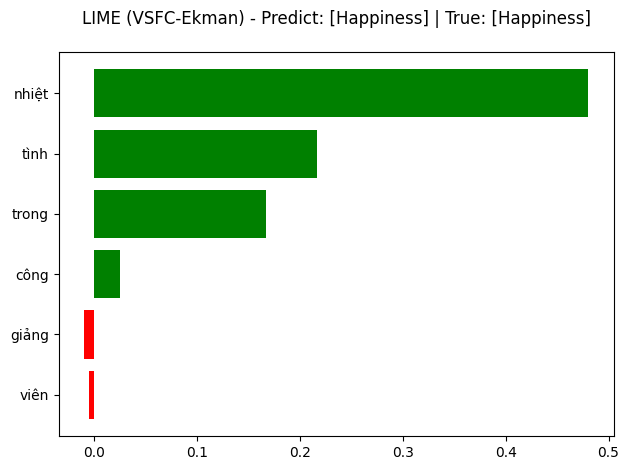

In [12]:
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from lime.lime_text import LimeTextExplainer

# Đảm bảo mô hình đang ở chế độ suy luận
m3.eval()

# ==========================================
# 1. HÀM PREDICT "BỌC THÉP" CHỐNG SEGFAULT
# ==========================================
def m3_predict_proba_bulletproof(texts):
    all_probs = []
    batch_size = 16 
    
    # Ép toàn bộ input về kiểu chuỗi (String) thuần túy
    clean_texts = [str(t) for t in texts]
    
    for i in range(0, len(clean_texts), batch_size):
        batch_texts = clean_texts[i:i+batch_size]
        
        # Tokenizer
        enc = tokenizer(batch_texts, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
        
        # Ontology
        ont_vectors = []
        for txt in batch_texts:
            try: 
                vec = ontengine.getvector(txt) 
            except: 
                vec = np.zeros(ONT_INPUT_DIM, dtype=np.float32)
            ont_vectors.append(vec)
            
        ids = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)
        ont = torch.tensor(np.array(ont_vectors), dtype=torch.float).to(device)
        
        with torch.no_grad():
            out = m3(ids, mask, ont)
            probs = F.softmax(out, dim=1).cpu().numpy()
            all_probs.extend(probs)
            
        del ids, mask, ont, out, enc
        torch.cuda.empty_cache()
        
    return np.array(all_probs)

# ==========================================
# 2. CHẠY LIME VÀ XUẤT ẢNH TĨNH CHO VSFC
# ==========================================
print("🚀 ĐANG CHẠY LIME VỚI CHẾ ĐỘ RENDER ẢNH (VSFC)...")
lime_explainer = LimeTextExplainer(class_names=le.classes_)

# Chọn câu test (Tập VSFC thường có các câu review ngắn)
test_idx = 10
text_test = str(df_test.iloc[test_idx]['Sentence']) 
true_label = df_test.iloc[test_idx]['Emotion']

# Chạy giải thích
lime_exp = lime_explainer.explain_instance(
    text_test, 
    m3_predict_proba_bulletproof, 
    num_features=6, 
    top_labels=1,
    num_samples=100 
)

print(f"\n> Text Gốc: {text_test}")
print(f"> True Label: {true_label}")

# Xuất bằng Matplotlib
top_pred_idx = lime_exp.available_labels()[0]
pred_label_name = le.classes_[top_pred_idx]

fig = lime_exp.as_pyplot_figure(label=top_pred_idx)
plt.title(f"LIME (VSFC-Ekman) - Predict: [{pred_label_name}] | True: [{true_label}]", pad=20)
plt.tight_layout()
plt.show()

🚀 ĐANG KHỞI ĐỘNG SHAP EXPLAINER CHO VSFC...

> Text Gốc: giảng viên nhiệt tình trong công tác giảng dạy .
> True Label: Happiness
> Model Predict: Happiness (Xác suất: 1.00)
⏳ Đang tính toán Shapley Values...

📊 Đang xuất biểu đồ...


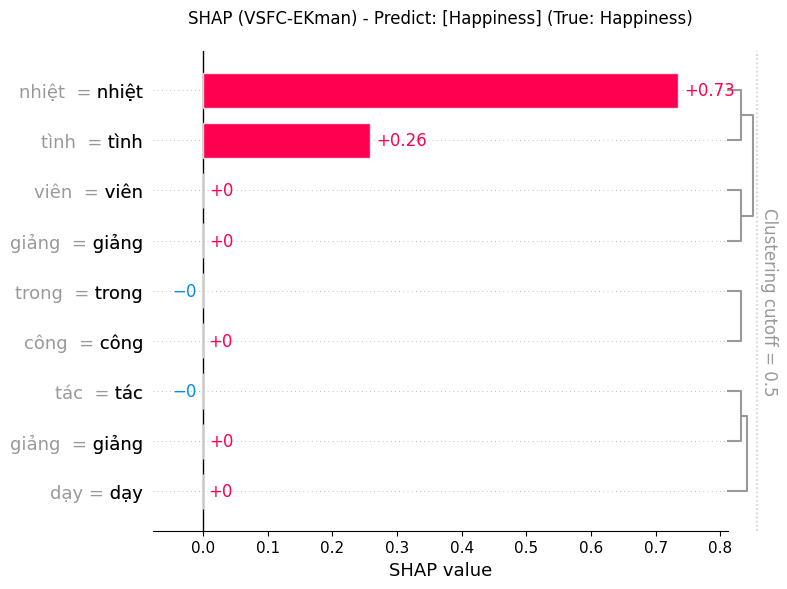

In [13]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Đảm bảo mô hình đang ở chế độ suy luận
m3.eval()

print("🚀 ĐANG KHỞI ĐỘNG SHAP EXPLAINER CHO VSFC...")

# 1. MASKER AN TOÀN: Tránh lỗi Tokenizer
masker = shap.maskers.Text(r"\W+")

# 2. KHỞI TẠO EXPLAINER
shap_explainer = shap.Explainer(m3_predict_proba_bulletproof, masker, output_names=le.classes_)

# 3. CHUẨN BỊ DỮ LIỆU TEST
test_idx = 10
text_test = str(df_test.iloc[test_idx]['Sentence'])
true_label = df_test.iloc[test_idx]['Emotion']

probs = m3_predict_proba_bulletproof([text_test])[0]
pred_idx = np.argmax(probs)
pred_label = le.classes_[pred_idx]

print(f"\n> Text Gốc: {text_test}")
print(f"> True Label: {true_label}")
print(f"> Model Predict: {pred_label} (Xác suất: {probs[pred_idx]:.2f})")
print("⏳ Đang tính toán Shapley Values...")

# 4. CHẠY SHAP (GIỚI HẠN TÀI NGUYÊN)
shap_values = shap_explainer([text_test], max_evals=150, batch_size=16)

# 5. VẼ BIỂU ĐỒ MATPLOTLIB
print("\n📊 Đang xuất biểu đồ...")
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Bar cho nhãn dự đoán cao nhất
shap.plots.bar(shap_values[0, :, pred_idx], show=False)

plt.title(f"SHAP (VSFC-EKman) - Predict: [{pred_label}] (True: {true_label})", pad=20)
plt.tight_layout()
plt.show()

🚀 ĐANG TÍNH TOÁN VÀ VẼ BIỂU ĐỒ ROC CHO VSFC...


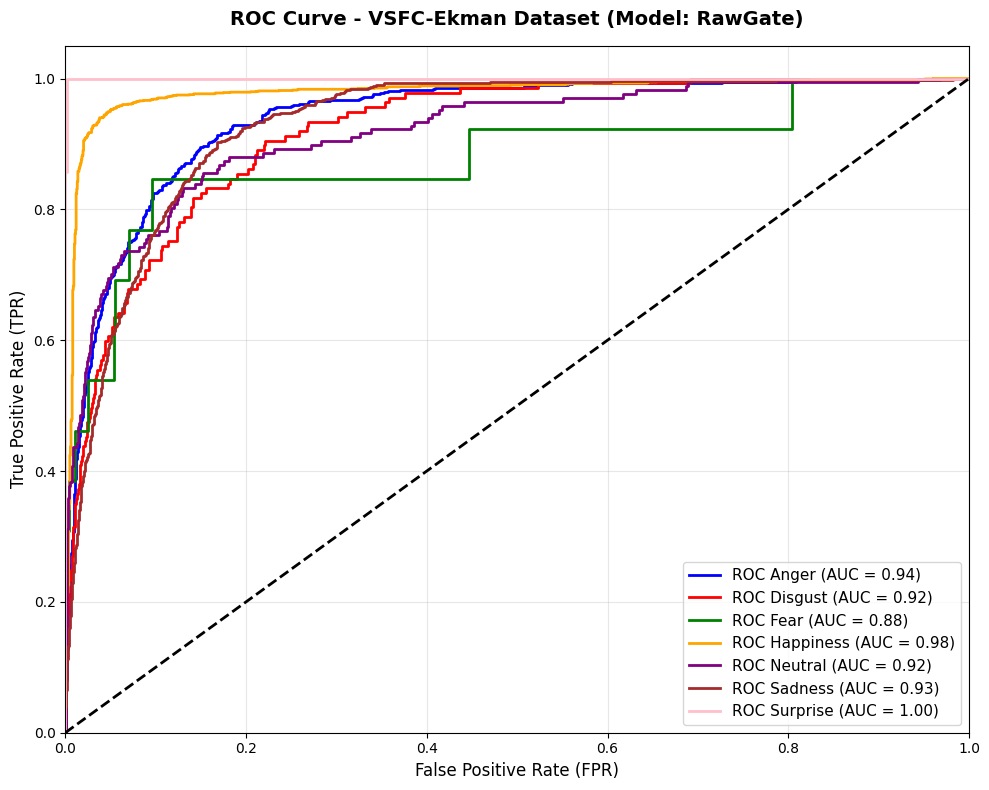

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
import numpy as np
import torch

# Đảm bảo mô hình ở chế độ suy luận
m3.eval()

def plot_multiclass_roc(model, loader, device, classes):
    y_test = []
    y_score = []
    
    # 1. Thu thập xác suất dự đoán (probabilities) cho toàn bộ tập Test
    with torch.no_grad():
        for b in loader:
            ids = b['input_ids'].to(device)
            mask = b['attention_mask'].to(device)
            ont = b['ontology_features'].to(device)
            labels = b['labels'].to(device)

            outputs = model(ids, mask, ont)
            probs = F.softmax(outputs, dim=1)

            y_test.extend(labels.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_test = np.array(y_test)
    y_score = np.array(y_score)
    
    # 2. Binarize nhãn thực tế để tính Multiclass ROC (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=range(len(classes)))
    n_classes = len(classes)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # Tính FPR, TPR và AUC cho từng class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # 3. Tiến hành vẽ biểu đồ
    plt.figure(figsize=(10, 8))
    
    # Tự động chọn màu dựa trên số lượng nhãn (VSFC có 3 nhãn)
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink'][:n_classes]
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC {0} (AUC = {1:0.2f})'.format(classes[i], roc_auc[i]))

    # Vẽ đường chéo ngẫu nhiên (Baseline 0.5)
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    # Tinh chỉnh giao diện
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('ROC Curve - VSFC-Ekman Dataset (Model: RawGate)', fontsize=14, fontweight='bold', pad=15)
    plt.legend(loc="lower right", fontsize=11)
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("🚀 ĐANG TÍNH TOÁN VÀ VẼ BIỂU ĐỒ ROC CHO VSFC...")
plot_multiclass_roc(m3, test_loader, device, le.classes_)